## Setup

Use the same set up but remove the consistent random seed

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

## Load, reduce, and split the data


In [2]:
data = load_breast_cancer()
X = data.data
y = data.target

X_scaled = StandardScaler().fit_transform(X)
X = PCA(n_components=2).fit_transform(X_scaled)
y = y * 2 - 1
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, stratify=y, random_state=0)

## Scale features for angle encoding

In [3]:
scaler = MinMaxScaler((-np.pi, np.pi)).fit(Xtr)
Xtr = scaler.transform(Xtr)
Xte = np.clip(scaler.transform(Xte), -np.pi, np.pi)

Xtr = pnp.array(Xtr)
ytr = pnp.array(ytr, dtype=float)

## Create the data-reuploading VQC

In [4]:
n_qubits = 2
n_layers = 3
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, diff_method="backprop")
def circuit(weights, x):
    for L in range(n_layers):
        qml.AngleEmbedding(x, wires=range(n_qubits))     
        for i in range(n_qubits):
            qml.Rot(weights[L, i, 0], weights[L, i, 1], weights[L, i, 2], wires=i)
        qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(0))

def model(weights, bias, x):
    return circuit(weights, x) + bias

## Generate model output over an input grid

Evaluate the trained model across the 2D feature space so the decision surface can be seen.

In [5]:
n_grid = 100

g = np.linspace(-np.pi, np.pi, n_grid)
GX, GY = np.meshgrid(g, g)
grid = np.column_stack([GX.ravel(), GY.ravel()])

## Fourier transform on the decision surfaces

Applies a 2D fourier transform to both of the decision surfaces to take the  spectrum magnitudes, showing which waves each model used.

In [6]:
def magnitude_spectrum(Z):
    F = np.fft.fft2(Z)
    F = np.fft.fftshift(F)
    return np.abs(F) / Z.size


# frequency index for each row/column (0 at center, +/- outward)
freqs = np.fft.fftshift(np.fft.fftfreq(n_grid, d=1.0 / n_grid))

## Train re-uploading VQC with 5 different seeds

Trains the re-uploading VQC five times, only the random seed changes per run. This will show whether the accuracy and dominant frequencies are stable

In [8]:
n_runs = 5
seeds = list(range(n_runs))

results = []
loss_curves = []

for seed in seeds:
    np.random.seed(seed)

    def cost(weights, bias, X, Y):
        preds = pnp.stack([model(weights, bias, x) for x in X])
        return pnp.mean((Y - preds) ** 2)

    weights = pnp.array(0.01 * np.random.randn(n_layers, n_qubits, 3), requires_grad=True)
    bias = pnp.array(0.0, requires_grad=True)
    opt = qml.NesterovMomentumOptimizer(0.2)

    loss_history = []
    for step in range(40):
        weights, bias, _, _ = opt.step(cost, weights, bias, Xtr, ytr)
        loss_history.append(float(cost(weights, bias, Xtr, ytr)))

    pred = np.array([1 if model(weights, bias, x) > 0 else -1 for x in Xte])
    yt = np.where(yte == -1, 0, 1)
    yp = np.where(pred == -1, 0, 1)
    acc = accuracy_score(yt, yp)
    f1 = f1_score(yt, yp)

    Z = np.array([float(model(weights, bias, pnp.array(p))) for p in grid]).reshape(GX.shape)
    S = magnitude_spectrum(Z)

    center = n_grid // 2
    S_nozero = S.copy()
    S_nozero[center, center] = 0
    i, j = np.unravel_index(np.argmax(S_nozero), S.shape)
    top_freq = (int(freqs[j]), int(freqs[i]))
    top_mag = round(float(S_nozero[i, j]), 4)

    results.append({"seed": seed, "accuracy": round(acc, 4), "f1": round(f1, 4),
                    "top freq": top_freq, "top magnitude": top_mag})
    loss_curves.append(loss_history)

    print(f"seed {seed}: acc={acc:.3f} f1={f1:.3f} top freq={top_freq} mag={top_mag}", flush=True)

seed 0: acc=0.909 f1=0.927 top freq=(-1, 0) mag=0.4613
seed 1: acc=0.909 f1=0.928 top freq=(-1, 0) mag=0.4629
seed 2: acc=0.909 f1=0.927 top freq=(-1, 0) mag=0.4598
seed 3: acc=0.902 f1=0.922 top freq=(-1, 0) mag=0.4894
seed 4: acc=0.909 f1=0.927 top freq=(-1, 0) mag=0.4717


## Summary table across runs

The accuracy, F1, top frequency, and its magnitude for each of the five runs.

In [9]:
summary = pd.DataFrame(results)
summary

,seed,accuracy,f1,top freq,top magnitude
0,0,0.9091,0.9274,"(-1, 0)",0.4613
1,1,0.9091,0.9282,"(-1, 0)",0.4629
2,2,0.9091,0.9274,"(-1, 0)",0.4598
3,3,0.9021,0.9222,"(-1, 0)",0.4894
4,4,0.9091,0.9274,"(-1, 0)",0.4717


## Magnitude and loss across runs

The top frequency magnitude for each run, and the training loss curves for all five runs, to show how consistent the model is across different seeds.

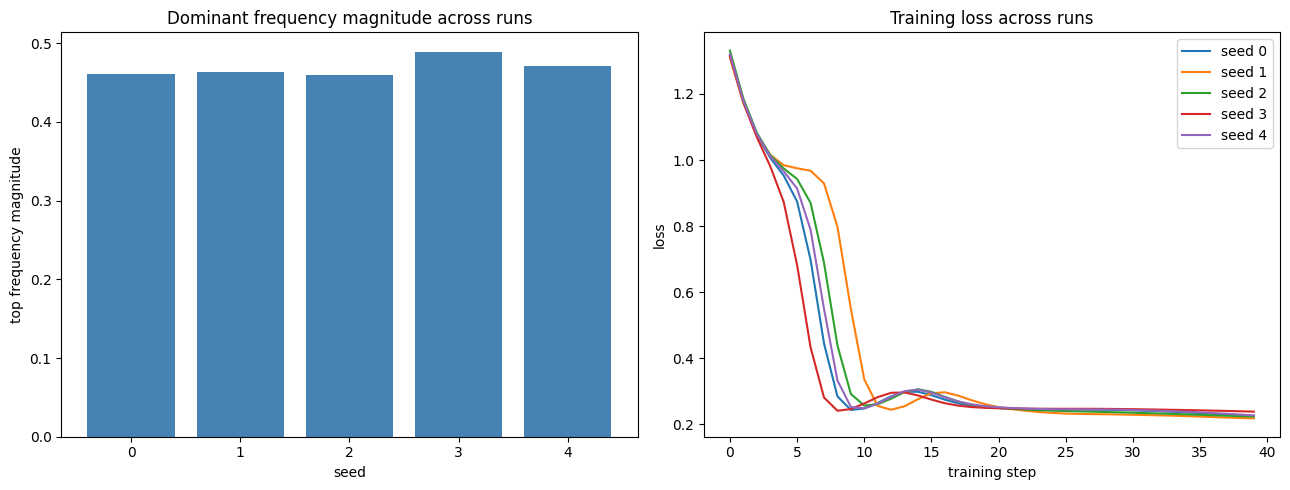

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

seeds_list = [r["seed"] for r in results]
mags = [r["top magnitude"] for r in results]
ax1.bar(seeds_list, mags, color="steelblue")
ax1.set_xlabel("seed")
ax1.set_ylabel("top frequency magnitude")
ax1.set_title("Dominant frequency magnitude across runs")
ax1.set_xticks(seeds_list)

for seed, curve in zip(seeds_list, loss_curves):
    ax2.plot(curve, label=f"seed {seed}")
ax2.set_xlabel("training step")
ax2.set_ylabel("loss")
ax2.set_title("Training loss across runs")
ax2.legend()

plt.tight_layout()
plt.show()